## Predicting High Value Customers

### Step 1: Load and Explore Customer Data
Load the dataset and check for missing values or basic statistics.

In [1]:
import pandas as pd

# Load data
df = pd.read_csv('synthetic_retail_customers.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Summary statistics to understand spending and frequency patterns
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (1000, 7)

First 5 rows:
   customer_id  avg_spend_per_visit  visit_frequency_per_month  \
0         1001            43.708611                          5   
1         1002            95.564288                          4   
2         1003            75.879455                          2   
3         1004            63.879264                          5   
4         1005            24.041678                          8   

   menu_engagement_score  online_order_ratio  loyalty_years  is_high_value  
0               1.353385            0.433442              5              0  
1               9.795554            0.294992              5              1  
2               3.181183            0.016162              3              0  
3               6.969796            0.140819              3              1  
4               8.551897            0.438305              1              0  

Summary Statistics:
       customer_id  avg_spend_per_visit  visit_frequency_per_month  \
count  100

### Step 2: Visualize Key Features
Visualize spending, frequency, and channel preferences to see how they relate to customer value.

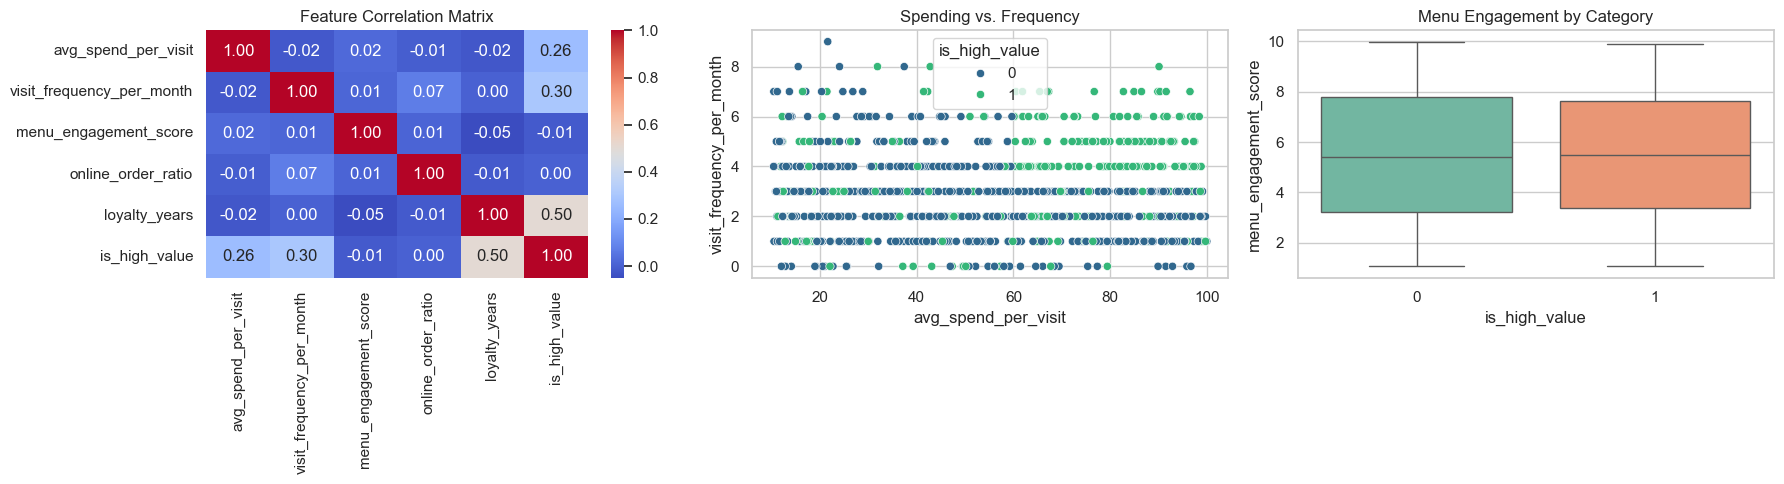

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with three plots to be extra thorough
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Correlation Heatmap (Great for spotting patterns early)
corr = df.drop(columns=["customer_id"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Feature Correlation Matrix")

# 2. Spending vs Visit Frequency (The core "Value" drivers)
sns.scatterplot(
    data=df,
    x="avg_spend_per_visit",
    y="visit_frequency_per_month",
    hue="is_high_value",
    palette="viridis",
    ax=ax[1],
)
ax[1].set_title("Spending vs. Frequency")

# 3. Menu Engagement (Fixed the Deprecation Warning)
sns.boxplot(
    data=df,
    x="is_high_value",
    y="menu_engagement_score",
    hue="is_high_value",
    palette="Set2",
    legend=False,
    ax=ax[2],
)
ax[2].set_title("Menu Engagement by Category")

plt.tight_layout()
plt.show()

### Step 3: Build and Test a Classification Model
We will use a Decision Tree to predict High-Value status and see which features are most important.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define Features (X) and Target (y)
X = df[
    [
        "avg_spend_per_visit",
        "visit_frequency_per_month",
        "menu_engagement_score",
        "online_order_ratio",
        "loyalty_years",
    ]
]
y = df["is_high_value"]

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train Decision Tree
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.50%

Confusion Matrix:
[[126   1]
 [  0  73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       127
           1       0.99      1.00      0.99        73

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



### Step 4: Interpret the Output and Business Implications
Find the most important features and discuss how to use this for marketing.

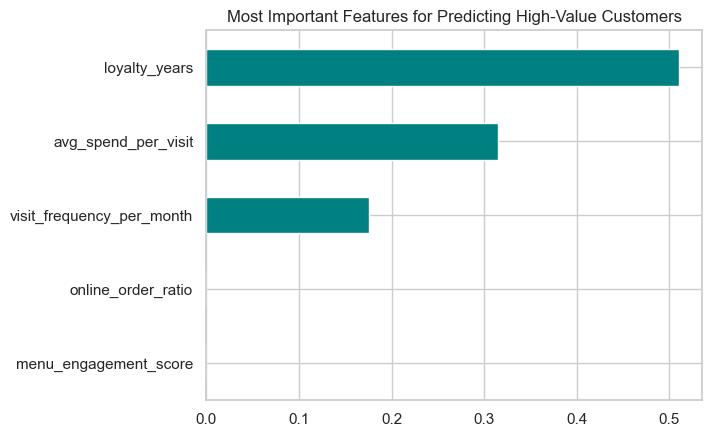

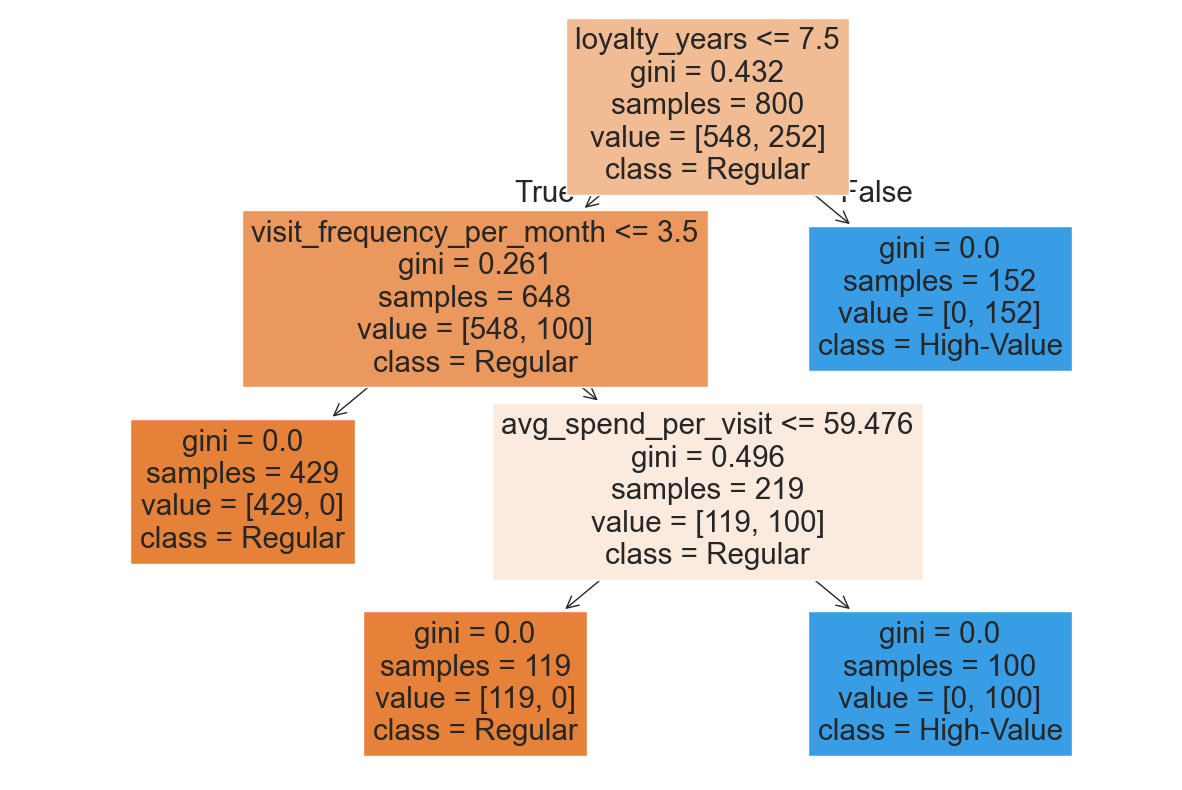

In [6]:
# Visualize Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", color="teal")
plt.title("Most Important Features for Predicting High-Value Customers")
plt.show()

# Visualize the Tree
plt.figure(figsize=(15, 10))
plot_tree(
    model, feature_names=X.columns, class_names=["Regular", "High-Value"], filled=True
)
plt.show()